# Visualization Notebook — Regression + Classification Charts

This notebook loads the same dataset, runs the same cleaning/encoding/modeling steps as the main pipeline, and plots every chart with **matplotlib** (data exploration, regression diagnostics, and classification evaluation).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                              accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

RAW_PATH = "linear_regression_preprocessing_dataset.csv"

## 1. Load & clean data

In [2]:
df_raw = pd.read_csv(RAW_PATH)

df = df_raw.copy()
df["City"] = df["City"].astype(str).str.strip().replace({"nan": np.nan, "": np.nan}).str.title()
city_mode = df["City"].mode()[0]
df["City"] = df["City"].fillna(city_mode)

numeric_cols = ["Study_Hours", "Attendance_Percent", "Assignments_Completed",
                 "Sleep_Hours", "Experience_Years"]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

target_col = "Expected_Salary_LPA"
df = df.dropna(subset=[target_col])

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (100, 8)


,Student_ID,Study_Hours,Attendance_Percent,Assignments_Completed,Sleep_Hours,Experience_Years,City,Expected_Salary_LPA
0,1001,4.4,56.4,9.0,4.8,3.0,Delhi,95.33
1,1002,9.6,83.6,5.0,8.9,1.0,Noida,132.11
2,1003,7.6,69.1,2.0,8.2,4.0,Gurgaon,115.16
3,1004,6.4,77.9,9.0,8.3,0.0,Noida,104.31
4,1005,2.4,95.8,5.0,5.3,7.0,Noida,98.87


## Chart 1 — Missing values per column (before cleaning)

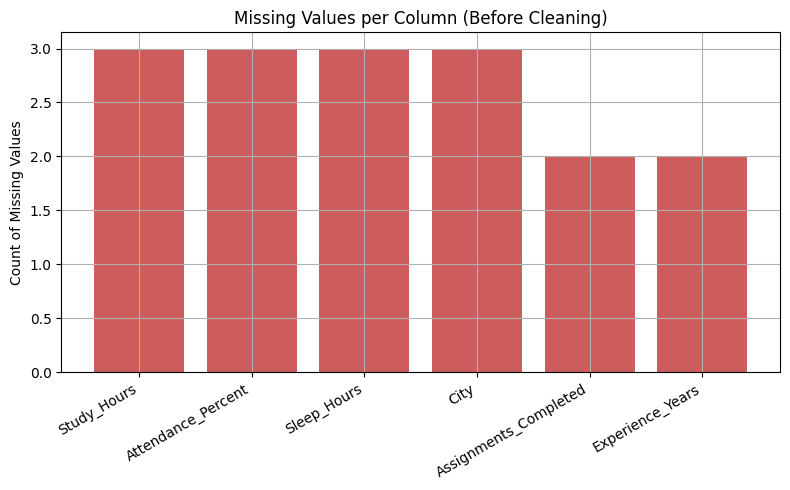

In [3]:
missing_counts = df_raw.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure()
plt.bar(missing_counts.index, missing_counts.values, color="indianred")
plt.title("Missing Values per Column (Before Cleaning)")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Chart 2 — City value counts (raw vs. cleaned)

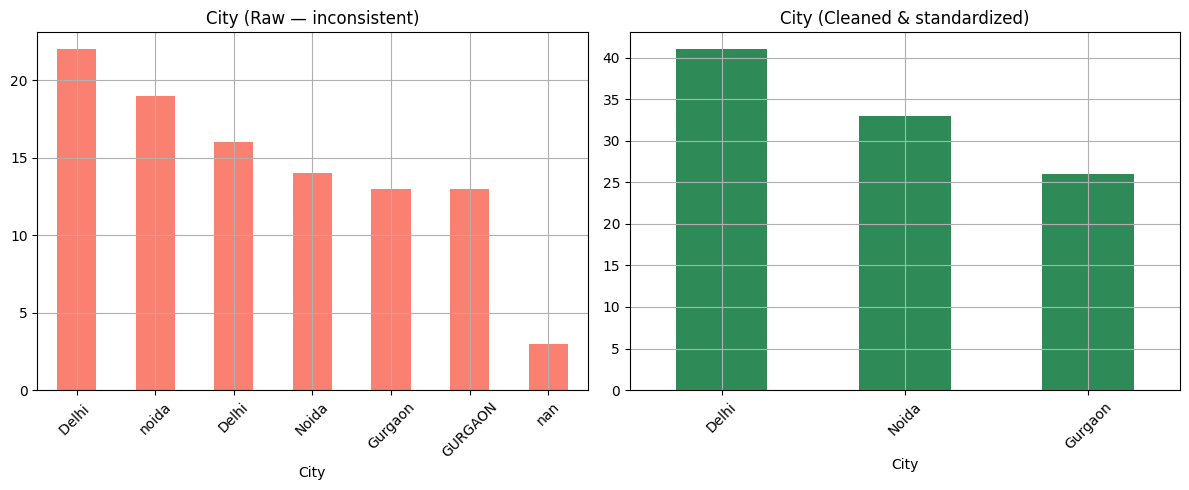

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_raw["City"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("City (Raw — inconsistent)")
axes[0].tick_params(axis="x", rotation=45)

df["City"].value_counts().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("City (Cleaned & standardized)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Chart 3 — Distributions of numeric features

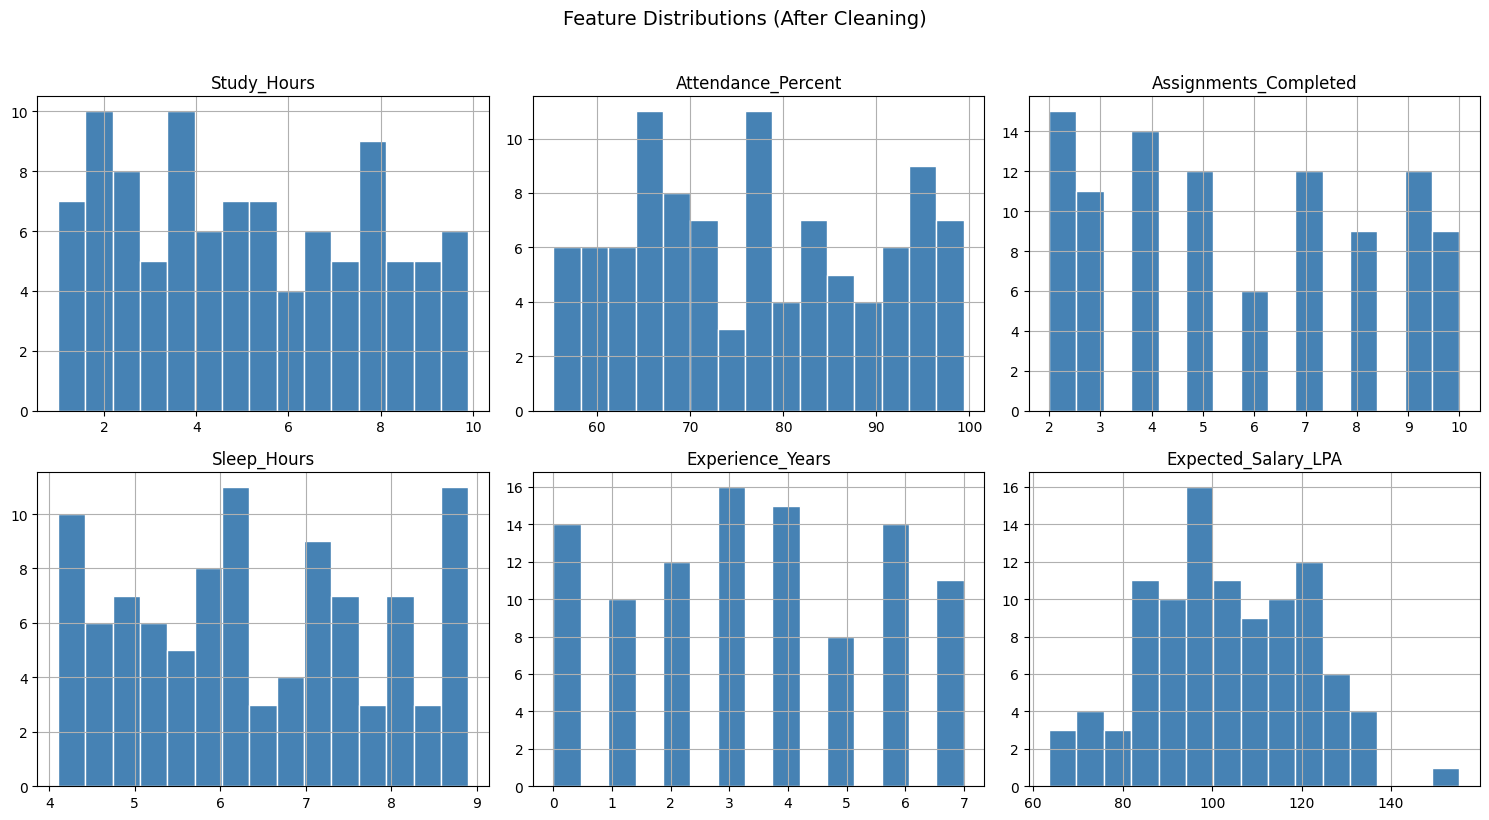

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_cols = numeric_cols + [target_col]
for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=15, color="steelblue", edgecolor="white")
    axes[i].set_title(col)

for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distributions (After Cleaning)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Chart 4 — Correlation heatmap

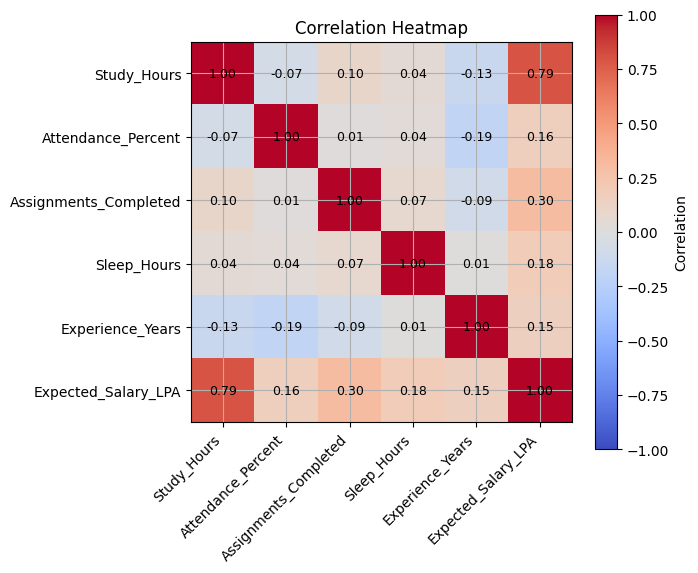

In [6]:
corr = df[numeric_cols + [target_col]].corr()

plt.figure(figsize=(7, 6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                  color="black", fontsize=9)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Chart 5 — Each feature vs. Expected_Salary_LPA

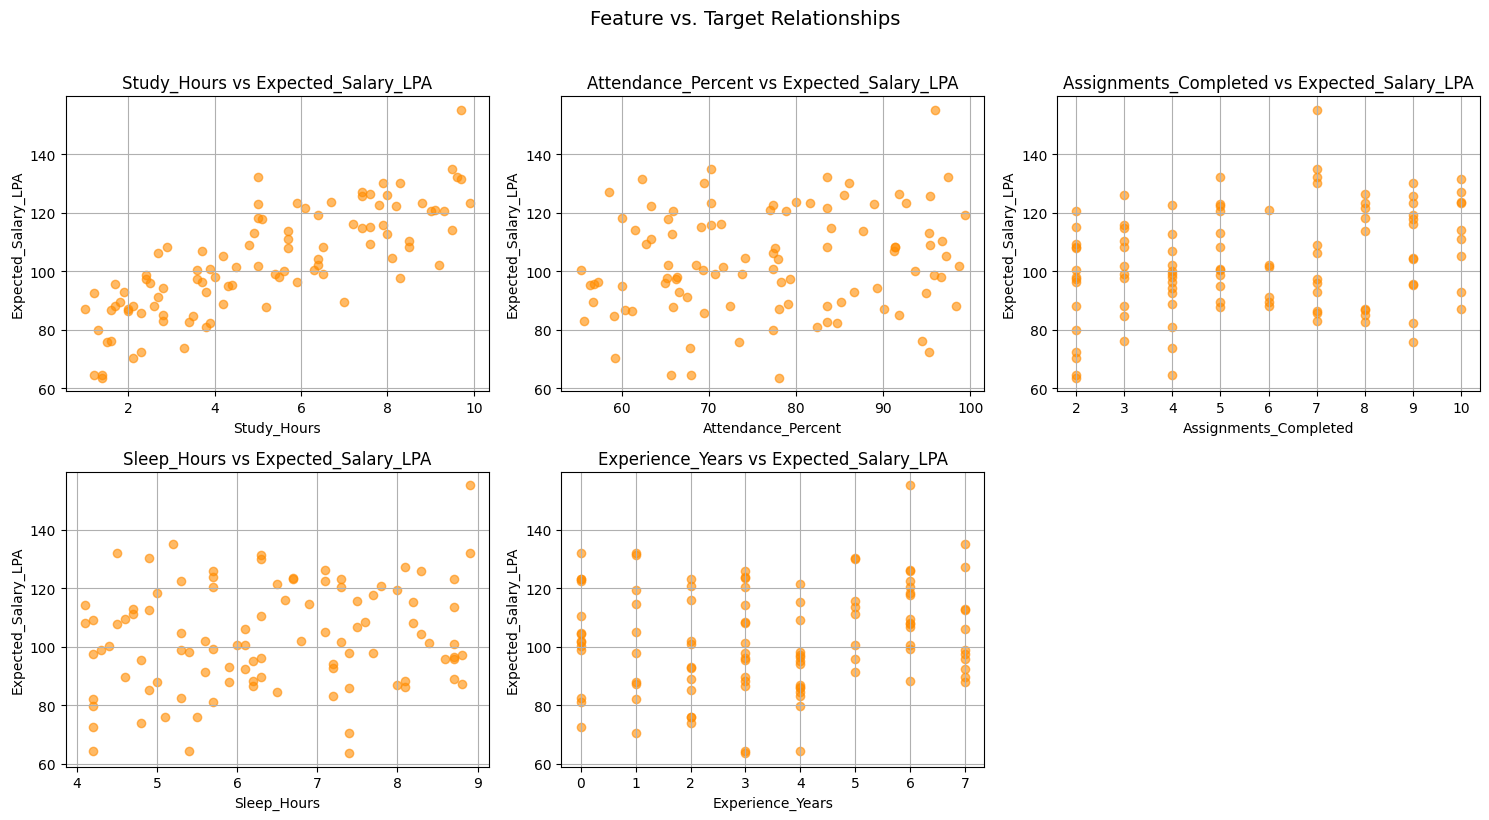

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(df[col], df[target_col], alpha=0.6, color="darkorange")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].set_title(f"{col} vs {target_col}")

fig.delaxes(axes[-1])
plt.suptitle("Feature vs. Target Relationships", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Chart 6 — Salary distribution by City

/tmp/ipykernel_85/4034840510.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_city, labels=cities)


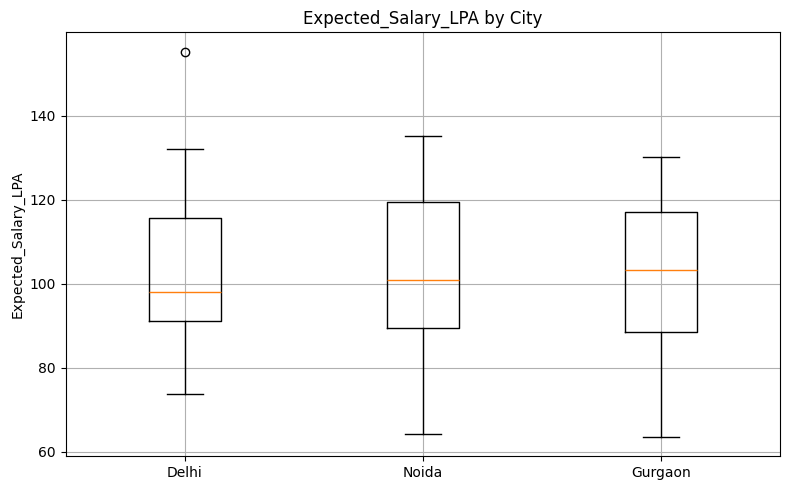

In [8]:
cities = df["City"].unique()
data_by_city = [df[df["City"] == c][target_col].values for c in cities]

plt.figure()
plt.boxplot(data_by_city, labels=cities)
plt.title("Expected_Salary_LPA by City")
plt.ylabel("Expected_Salary_LPA")
plt.tight_layout()
plt.show()

## 2. Train the regression model (for diagnostic charts)

In [9]:
df_encoded = pd.get_dummies(df, columns=["City"], drop_first=True)
feature_cols = numeric_cols + [c for c in df_encoded.columns if c.startswith("City_")]

X = df_encoded[feature_cols]
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred_test = reg_model.predict(X_test)

r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"R2={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")

R2=0.9259  MAE=4.2249  RMSE=5.3656


## Chart 7 — Regression coefficients

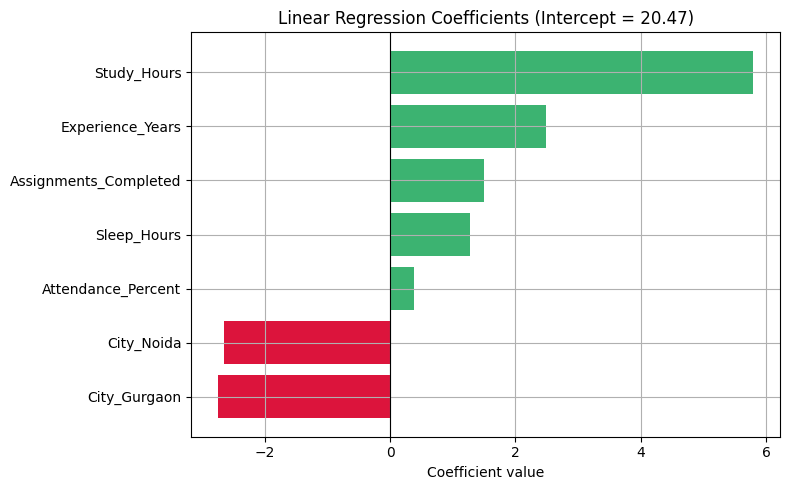

In [10]:
coef_series = pd.Series(reg_model.coef_, index=feature_cols).sort_values()

plt.figure()
colors = ["crimson" if v < 0 else "mediumseagreen" for v in coef_series.values]
plt.barh(coef_series.index, coef_series.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Linear Regression Coefficients (Intercept = {reg_model.intercept_:.2f})")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

## Chart 8 — Actual vs. Predicted (test set)

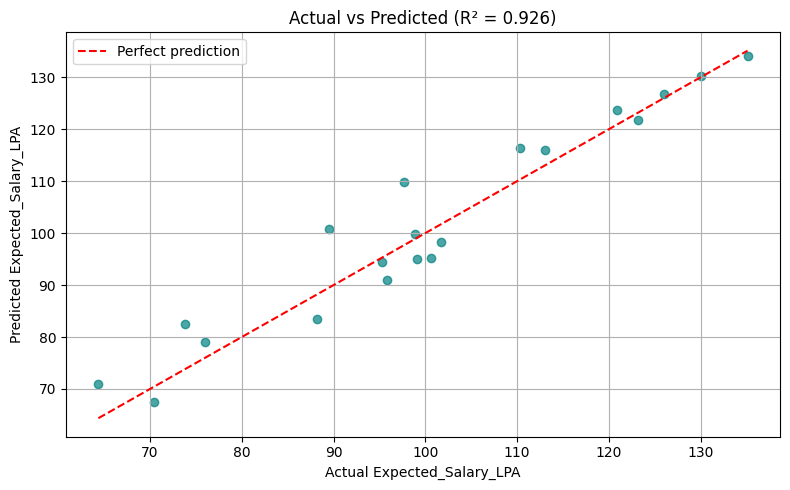

In [11]:
plt.figure()
plt.scatter(y_test, y_pred_test, alpha=0.7, color="teal")
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Expected_Salary_LPA")
plt.ylabel("Predicted Expected_Salary_LPA")
plt.title(f"Actual vs Predicted (R² = {r2:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

## Chart 9 — Residual plot

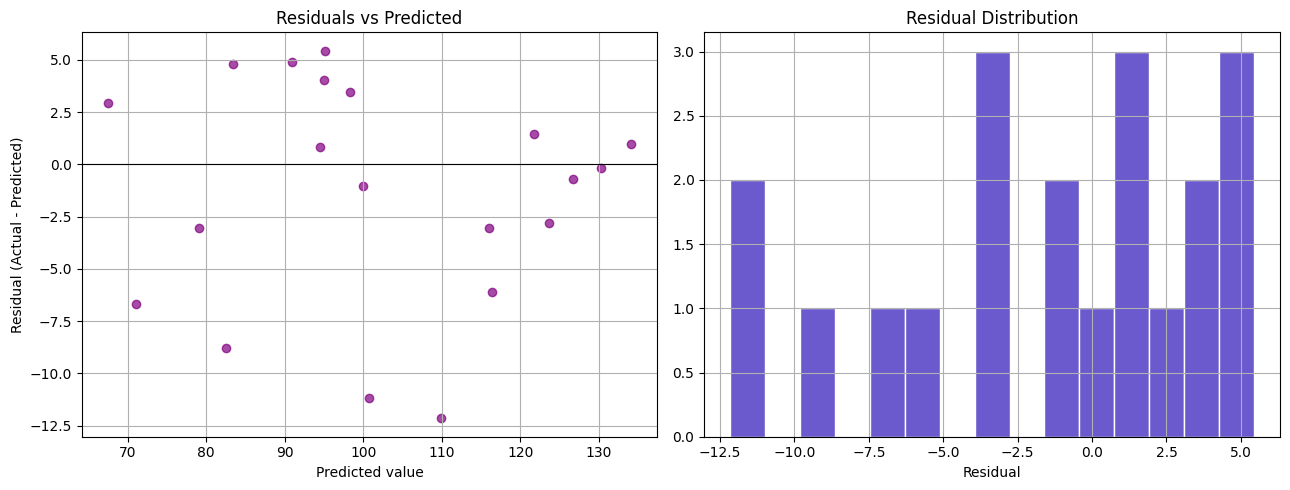

In [12]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_test, residuals, alpha=0.7, color="purple")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Predicted value")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=15, color="slateblue", edgecolor="white")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

## 3. Classification: salary bands (Low / Medium / High)

In [13]:
df_clf = df.copy()
df_clf["Salary_Band"] = pd.qcut(df_clf[target_col], q=3, labels=["Low", "Medium", "High"])

df_clf_encoded = pd.get_dummies(df_clf, columns=["City"], drop_first=True)
clf_feature_cols = numeric_cols + [c for c in df_clf_encoded.columns if c.startswith("City_")]

X_clf = df_clf_encoded[clf_feature_cols]
le = LabelEncoder()
y_clf = le.fit_transform(df_clf_encoded["Salary_Band"])

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(Xc_train_scaled, yc_train)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(Xc_train, yc_train)

y_pred_log = log_reg.predict(Xc_test_scaled)
y_pred_rf = rf_clf.predict(Xc_test)

def get_metrics(y_true, y_pred):
    return (accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, average="weighted", zero_division=0),
            recall_score(y_true, y_pred, average="weighted", zero_division=0),
            f1_score(y_true, y_pred, average="weighted", zero_division=0))

log_metrics = get_metrics(yc_test, y_pred_log)
rf_metrics = get_metrics(yc_test, y_pred_rf)
print("Logistic Regression -> Acc/Prec/Rec/F1:", [f"{m:.3f}" for m in log_metrics])
print("Random Forest       -> Acc/Prec/Rec/F1:", [f"{m:.3f}" for m in rf_metrics])

Logistic Regression -> Acc/Prec/Rec/F1: ['0.900', '0.906', '0.900', '0.900']
Random Forest       -> Acc/Prec/Rec/F1: ['0.850', '0.872', '0.850', '0.846']


## Chart 10 — Salary band distribution

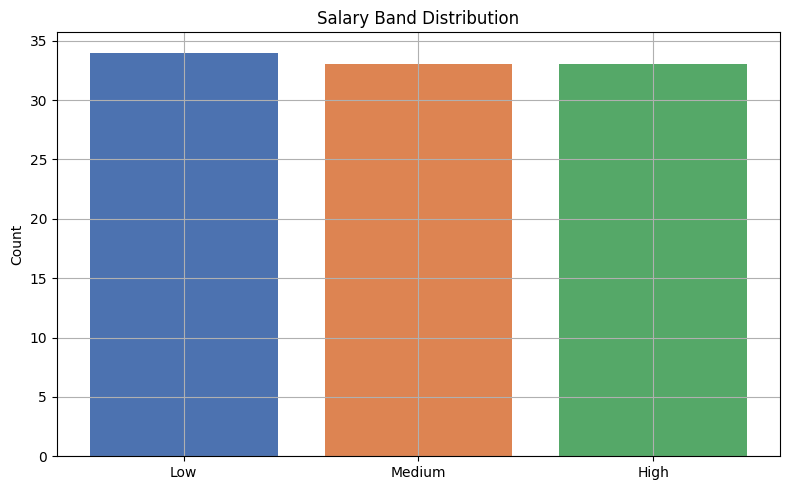

In [14]:
band_counts = df_clf["Salary_Band"].value_counts().reindex(["Low", "Medium", "High"])

plt.figure()
plt.bar(band_counts.index, band_counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Salary Band Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Chart 11 — Model comparison: Accuracy, Precision, Recall, F1

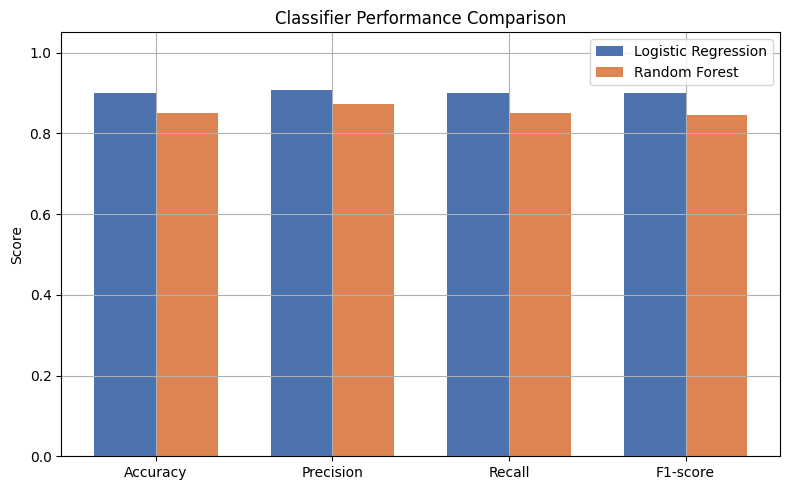

In [15]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics_names))
width = 0.35

plt.figure()
plt.bar(x - width/2, log_metrics, width, label="Logistic Regression", color="#4C72B0")
plt.bar(x + width/2, rf_metrics, width, label="Random Forest", color="#DD8452")
plt.xticks(x, metrics_names)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Chart 12 — Confusion matrices

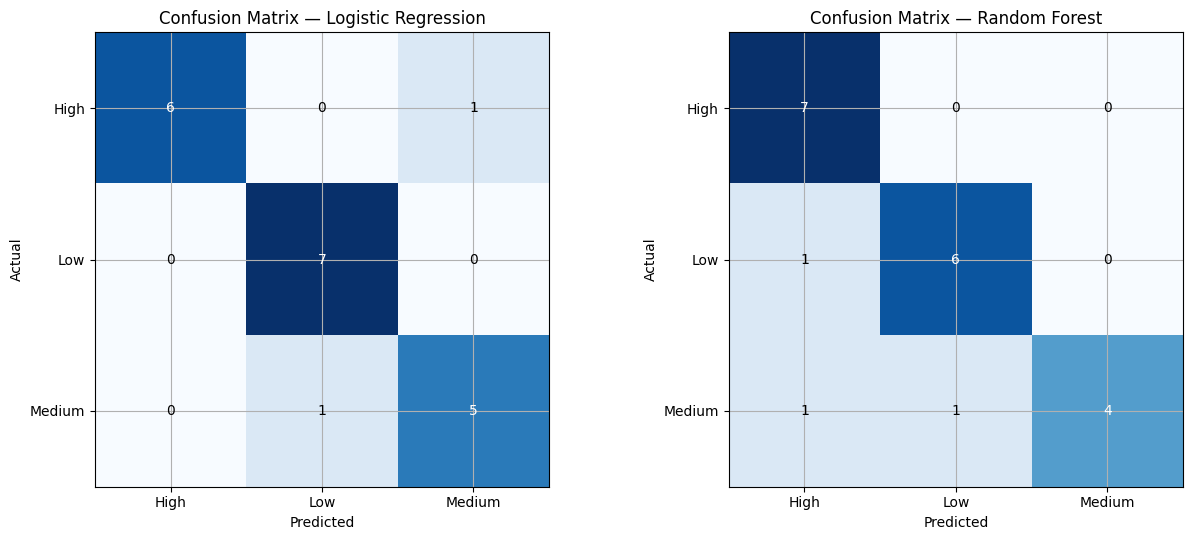

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, y_pred, title in zip(axes, [y_pred_log, y_pred_rf],
                              ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(yc_test, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(le.classes_)))
    ax.set_yticks(range(len(le.classes_)))
    ax.set_xticklabels(le.classes_)
    ax.set_yticklabels(le.classes_)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {title}")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.show()

## Chart 13 — Feature importance (Random Forest classifier)

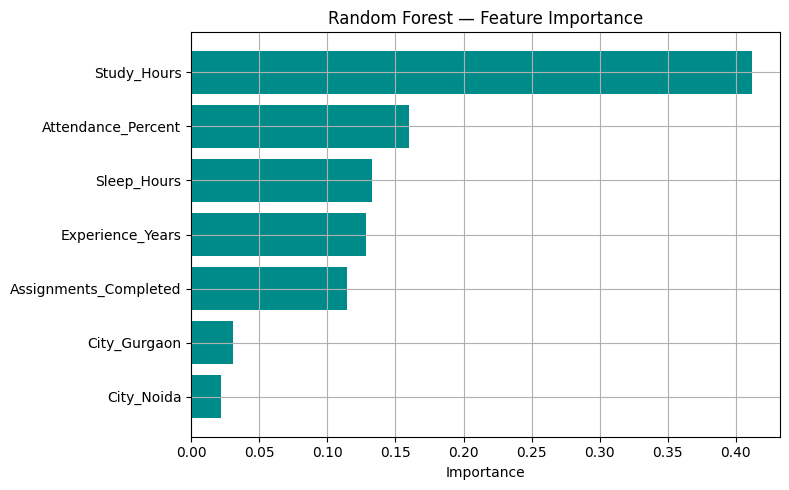

In [17]:
importances = pd.Series(rf_clf.feature_importances_, index=clf_feature_cols).sort_values()

plt.figure()
plt.barh(importances.index, importances.values, color="darkcyan")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()